# Meta-Feature Combination Study - Business Threshold Optimization

## Research Goal

This notebook evaluates whether the full five-model stacking ensemble is required.

The goal is to find a smaller and more efficient meta-feature combination that keeps fraud recall high while reducing false alerts.

The business objectives are:

- Maintain high fraud recall
- Reduce false alerts
- Use fewer models when performance remains similar
- Select a separate decision threshold for each model combination

# Initial Setup

## Install and Import Libraries

In [ ]:
%%capture
!pip install -q ipython-autotime
!pip install -q gdown
%load_ext autotime

time: 8.7 s (started: 2026-06-18 07:44:18 +00:00)


In [ ]:
import os
import itertools
import warnings
import joblib

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import gdown

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    balanced_accuracy_score,
    ConfusionMatrixDisplay,
)

time: 801 µs (started: 2026-06-18 07:57:29 +00:00)


## Global Parameters

In [ ]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

LABELS = ["Legitimate", "Fraud"]

META_FEATURES = [
    "rf_prob",
    "lgbm_prob",
    "cat_prob",
    "xgb_prob",
    "nn_prob",
]

FEATURE_DISPLAY_NAMES = {
    "rf_prob": "RF",
    "lgbm_prob": "LGBM",
    "cat_prob": "CAT",
    "xgb_prob": "XGB",
    "nn_prob": "NN",
}

MINIMUM_RECALL = 0.95
THRESHOLD_STEP = 0.01
THRESHOLDS = np.round(np.arange(0.30, 0.90, 0.01), 2)

TOP_N_TO_DISPLAY = 31

print("Meta feature order:")
print(META_FEATURES)

print("\nBusiness constraint:")
print("Minimum Recall:", MINIMUM_RECALL)
print("Threshold step:", THRESHOLD_STEP)
print("Number of thresholds:", len(THRESHOLDS))

Meta feature order:
['rf_prob', 'lgbm_prob', 'cat_prob', 'xgb_prob', 'nn_prob']

Business constraint:
Minimum Recall: 0.95
Threshold step: 0.01
Number of thresholds: 61
time: 1.33 ms (started: 2026-06-18 07:44:26 +00:00)


## Project Directories

In [ ]:
PROJECT_DIR = "/content/meta_feature_combination_study"

ARTIFACT_DIR = "/content/fraud_stacking_artifacts"
REPORTS_DIR = os.path.join(PROJECT_DIR, "reports")
FIGURES_DIR = os.path.join(PROJECT_DIR, "figures")
COEFFICIENTS_DIR = os.path.join(REPORTS_DIR, "coefficients")
THRESHOLD_DIR = os.path.join(REPORTS_DIR, "threshold_sweeps")

os.makedirs(PROJECT_DIR, exist_ok=True)
os.makedirs(ARTIFACT_DIR, exist_ok=True)
os.makedirs(REPORTS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(COEFFICIENTS_DIR, exist_ok=True)
os.makedirs(THRESHOLD_DIR, exist_ok=True)

print("Project Directory:", PROJECT_DIR)
print("Artifact Directory:", ARTIFACT_DIR)
print("Reports Directory:", REPORTS_DIR)
print("Figures Directory:", FIGURES_DIR)
print("Coefficients Directory:", COEFFICIENTS_DIR)
print("Threshold Directory:", THRESHOLD_DIR)

Project Directory: /content/meta_feature_combination_study
Artifact Directory: /content/fraud_stacking_artifacts
Reports Directory: /content/meta_feature_combination_study/reports
Figures Directory: /content/meta_feature_combination_study/figures
Coefficients Directory: /content/meta_feature_combination_study/reports/coefficients
Threshold Directory: /content/meta_feature_combination_study/reports/threshold_sweeps
time: 1.67 ms (started: 2026-06-18 07:44:26 +00:00)


## Download Saved Meta-Feature Artifacts with gdown

This notebook downloads only the CSV files required for the combination study.

No base models are downloaded.

No base models are retrained.

Each combination trains only a small Logistic Regression meta-model on saved OOF probabilities.

In [ ]:
artifact_file_ids = {
    "oof_meta_dataset.csv": "18wPvWF-nYbDqOgRqZid9lM873PGjAov3",
    "test_meta_features.csv": "1Ebs-FusNR9e0eH8hMO320vPNTNUeIQqV",
    "final_stacking_predictions.csv": "1mzOt8joiR_2BEE52f82oCKRQcsh1xTIw",
}

artifact_paths = {}

for filename, file_id in artifact_file_ids.items():
    output_path = os.path.join(
        ARTIFACT_DIR,
        filename
    )

    artifact_paths[filename] = output_path

    url = f"https://drive.google.com/uc?id={file_id}"

    gdown.download(
        url,
        output_path,
        quiet=False
    )

print("\nAll artifacts downloaded successfully.")

for path in artifact_paths.values():
    assert os.path.exists(path)

print("\nArtifact paths:")

for name, path in artifact_paths.items():
    print(name, "->", path)

Downloading...
From (original): https://drive.google.com/uc?id=18wPvWF-nYbDqOgRqZid9lM873PGjAov3
From (redirected): https://drive.google.com/uc?id=18wPvWF-nYbDqOgRqZid9lM873PGjAov3&confirm=t&uuid=3fca4930-1f77-4fe3-aaaa-3ca59901bea2
To: /content/fraud_stacking_artifacts/oof_meta_dataset.csv
100%|██████████| 123M/123M [00:00<00:00, 137MB/s]
Downloading...
From: https://drive.google.com/uc?id=1Ebs-FusNR9e0eH8hMO320vPNTNUeIQqV
To: /content/fraud_stacking_artifacts/test_meta_features.csv
100%|██████████| 42.7M/42.7M [00:00<00:00, 98.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=1mzOt8joiR_2BEE52f82oCKRQcsh1xTIw
To: /content/fraud_stacking_artifacts/final_stacking_predictions.csv
100%|██████████| 56.5M/56.5M [00:00<00:00, 102MB/s]


All artifacts downloaded successfully.

Artifact paths:
oof_meta_dataset.csv -> /content/fraud_stacking_artifacts/oof_meta_dataset.csv
test_meta_features.csv -> /content/fraud_stacking_artifacts/test_meta_features.csv
final_stacking_predictions.csv -> /content/fraud_stacking_artifacts/final_stacking_predictions.csv
time: 9.41 s (started: 2026-06-18 07:44:26 +00:00)


## Load Saved Meta-Feature Datasets

In [ ]:
meta_train_df = pd.read_csv(
    artifact_paths["oof_meta_dataset.csv"]
)

meta_test_df = pd.read_csv(
    artifact_paths["test_meta_features.csv"]
)

final_predictions_df = pd.read_csv(
    artifact_paths["final_stacking_predictions.csv"]
)

print("OOF Meta Dataset Shape:", meta_train_df.shape)
print("Test Meta Features Shape:", meta_test_df.shape)
print("Final Predictions Shape:", final_predictions_df.shape)

display(meta_train_df.head())
display(meta_test_df.head())
display(final_predictions_df.head())

OOF Meta Dataset Shape: (1296675, 6)
Test Meta Features Shape: (555719, 6)
Final Predictions Shape: (555719, 9)


,rf_prob,lgbm_prob,cat_prob,xgb_prob,nn_prob,label
0,0.0,0.000170,0.015003,0.001511,0.458894,0
1,0.0,0.000034,0.000950,0.000230,0.000120,0
2,0.0,0.000205,0.002461,0.000829,0.625743,0
3,0.0,0.000207,0.001053,0.001499,0.002683,0
4,0.0,0.000133,0.000106,0.000802,0.009494,0


,rf_prob,lgbm_prob,cat_prob,xgb_prob,nn_prob,label
0,0.0,0.000360,0.000317,0.000304,0.020924,0
1,0.0,0.001150,0.001293,0.007654,0.020370,0
2,0.0,0.000143,0.000918,0.000497,0.014765,0
3,0.0,0.000085,0.000151,0.000329,0.002329,0
4,0.0,0.000460,0.001691,0.001084,0.023558,0


,y_true,rf_prob,lgbm_prob,cat_prob,xgb_prob,nn_prob,stacking_prob,stacking_pred,stacking_pred_optimized
0,0,0.0,0.000360,0.000317,0.000304,0.020924,0.013755,0,0
1,0,0.0,0.001150,0.001293,0.007654,0.020370,0.014045,0,0
2,0,0.0,0.000143,0.000918,0.000497,0.014765,0.013724,0,0
3,0,0.0,0.000085,0.000151,0.000329,0.002329,0.013538,0,0
4,0,0.0,0.000460,0.001691,0.001084,0.023558,0.013901,0,0


time: 2.12 s (started: 2026-06-18 07:44:36 +00:00)


## Validate Required Columns

This cell makes sure all required columns exist before running the experiments.

In [ ]:
REQUIRED_TRAIN_COLUMNS = META_FEATURES + ["label"]
REQUIRED_TEST_COLUMNS = META_FEATURES
REQUIRED_FINAL_PREDICTION_COLUMNS = ["y_true", "stacking_prob"]


def validate_columns(df, required_columns, dataframe_name):
    missing_columns = [col for col in required_columns if col not in df.columns]

    if missing_columns:
        raise ValueError(
            f"Missing columns in {dataframe_name}: {missing_columns}. "
            f"Available columns: {list(df.columns)}"
        )

    print(f"{dataframe_name}: all required columns exist.")


validate_columns(meta_train_df, REQUIRED_TRAIN_COLUMNS, "OOF meta dataset")
validate_columns(meta_test_df, REQUIRED_TEST_COLUMNS, "Test meta features")
validate_columns(final_predictions_df, REQUIRED_FINAL_PREDICTION_COLUMNS, "Final stacking predictions")

OOF meta dataset: all required columns exist.
Test meta features: all required columns exist.
Final stacking predictions: all required columns exist.
time: 1.11 ms (started: 2026-06-18 07:44:38 +00:00)


## Prepare Training and Test Labels

The new meta-models are trained on the saved OOF meta-features.

The evaluation labels are taken from `final_stacking_predictions.csv`, the same reference used by the inference notebook.

In [ ]:
y_meta_train = meta_train_df["label"].astype(int).values
y_test = final_predictions_df["y_true"].astype(int).values

print("OOF train labels:")
print(pd.Series(y_meta_train).value_counts().sort_index())

print("\nTest labels:")
print(pd.Series(y_test).value_counts().sort_index())

OOF train labels:
0    1289169
1       7506
Name: count, dtype: int64

Test labels:
0    553574
1      2145
Name: count, dtype: int64
time: 15.9 ms (started: 2026-06-18 07:44:38 +00:00)


# Helper Functions

## Evaluation Helper Functions

These functions evaluate each meta-model combination using a shared evaluation pipeline.

Threshold optimization is performed separately for every combination according to the business constraint.

In [ ]:
def clean_model_name(model_name):
    return (
        model_name.lower()
        .replace(" ", "_")
        .replace("+", "plus")
        .replace("-", "_")
        .replace("/", "_")
    )


def save_plot(fig, filename):
    path = os.path.join(FIGURES_DIR, filename)
    fig.savefig(path, bbox_inches="tight", dpi=150)
    print("Saved plot:", path)
    return path


def get_confusion_values(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    return {
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
    }


def evaluate_predictions(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)

    confusion_values = get_confusion_values(
        y_true,
        y_pred
    )

    scores = {
        "Threshold": float(threshold),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "PR-AUC": average_precision_score(y_true, y_prob),
        **confusion_values,
    }

    scores["False Alarm Rate"] = (
        scores["FP"] / max(scores["FP"] + scores["TN"], 1)
    )

    return scores, y_pred


def find_best_business_threshold(y_true, y_prob, thresholds, minimum_recall):
    threshold_rows = []

    for threshold in thresholds:
        scores, _ = evaluate_predictions(
            y_true=y_true,
            y_prob=y_prob,
            threshold=threshold
        )

        threshold_rows.append(scores)

    threshold_df = pd.DataFrame(threshold_rows)

    eligible_thresholds = threshold_df[
        threshold_df["Recall"] >= minimum_recall
    ].copy()

    if len(eligible_thresholds) == 0:
        best_row = threshold_df.sort_values(
            by=["Recall", "FP", "Precision"],
            ascending=[False, True, False]
        ).iloc[0].copy()

        best_row["Meets Minimum Recall"] = False

    else:
        best_row = eligible_thresholds.sort_values(
            by=["FP", "Precision", "Threshold"],
            ascending=[True, False, False]
        ).iloc[0].copy()

        best_row["Meets Minimum Recall"] = True

    return best_row, threshold_df


def plot_confusion_matrix(y_true, y_prob, threshold, title):
    y_pred = (y_prob >= threshold).astype(int)

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    display_cm = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=LABELS
    )

    fig, ax = plt.subplots(figsize=(6, 5))

    display_cm.plot(
        ax=ax,
        values_format="d",
        cmap="Blues",
        colorbar=False
    )

    ax.set_title(title)
    plt.grid(False)
    plt.tight_layout()
    plt.show()

    print("TN:", cm[0, 0])
    print("FP:", cm[0, 1])
    print("FN:", cm[1, 0])
    print("TP:", cm[1, 1])

    return fig

time: 2.67 ms (started: 2026-06-18 07:44:38 +00:00)


# Define All Meta-Feature Combinations

With five meta-features, there are **2^5 - 1 = 31** non-empty combinations.

This is the only place where all combinations are created.

After this point, the notebook focuses on business selection instead of repeated manual analysis.

In [ ]:
experiments = []

for combination_size in range(1, len(META_FEATURES) + 1):
    for feature_set in itertools.combinations(META_FEATURES, combination_size):
        readable_name = " + ".join(
            FEATURE_DISPLAY_NAMES[feature]
            for feature in feature_set
        )

        experiments.append({
            "model_name": readable_name,
            "feature_set": feature_set,
            "number_of_models": combination_size,
        })

print("Number of experiments:", len(experiments))

display(pd.DataFrame(experiments).head(10))

Number of experiments: 31


,model_name,feature_set,number_of_models
0,RF,"(rf_prob,)",1
1,LGBM,"(lgbm_prob,)",1
2,CAT,"(cat_prob,)",1
3,XGB,"(xgb_prob,)",1
4,NN,"(nn_prob,)",1
5,RF + LGBM,"(rf_prob, lgbm_prob)",2
6,RF + CAT,"(rf_prob, cat_prob)",2
7,RF + XGB,"(rf_prob, xgb_prob)",2
8,RF + NN,"(rf_prob, nn_prob)",2
9,LGBM + CAT,"(lgbm_prob, cat_prob)",2


time: 11.3 ms (started: 2026-06-18 07:44:38 +00:00)


# Train Meta-Models and Optimize Business Thresholds

Each experiment trains a Logistic Regression meta-model on one subset of saved OOF probabilities.

Then it performs a threshold sweep and selects the best threshold for the business goal.

This means that every combination is judged fairly according to its own best operating point.

In [ ]:
def train_meta_model(feature_set):
    X_meta_train = meta_train_df[list(feature_set)].copy()
    X_meta_test = meta_test_df[list(feature_set)].copy()

    meta_model = LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=RANDOM_STATE,
    )

    meta_model.fit(
        X_meta_train,
        y_meta_train
    )

    train_prob = meta_model.predict_proba(X_meta_train)[:, 1]
    test_prob = meta_model.predict_proba(X_meta_test)[:, 1]

    return meta_model, train_prob, test_prob


def save_coefficients(meta_model, feature_set, model_name):
    coefficients_df = pd.DataFrame({
        "Feature": list(feature_set),
        "Coefficient": meta_model.coef_[0],
    })

    coefficients_df["Absolute Coefficient"] = coefficients_df["Coefficient"].abs()
    coefficients_df = coefficients_df.sort_values(
        "Absolute Coefficient",
        ascending=False
    )

    coefficient_filename = clean_model_name(model_name) + "_coefficients.csv"
    coefficient_path = os.path.join(COEFFICIENTS_DIR, coefficient_filename)

    coefficients_df.to_csv(
        coefficient_path,
        index=False
    )

    return coefficients_df, coefficient_path

time: 2.03 ms (started: 2026-06-18 07:44:38 +00:00)


In [ ]:
all_results = []
trained_experiments = {}
threshold_sweeps = {}

for experiment in experiments:
    model_name = experiment["model_name"]
    feature_set = experiment["feature_set"]

    print("Running experiment:", model_name)

    meta_model, train_prob, test_prob = train_meta_model(
        feature_set=feature_set
    )

    best_threshold_row, threshold_df = find_best_business_threshold(
        y_true=y_test,
        y_prob=test_prob,
        thresholds=THRESHOLDS,
        minimum_recall=MINIMUM_RECALL
    )

    coefficients_df, coefficient_path = save_coefficients(
        meta_model=meta_model,
        feature_set=feature_set,
        model_name=model_name
    )

    threshold_filename = clean_model_name(model_name) + "_threshold_sweep.csv"
    threshold_path = os.path.join(THRESHOLD_DIR, threshold_filename)

    threshold_df.to_csv(
        threshold_path,
        index=False
    )

    result_row = {
        "Stack Version": model_name,
        "Number of Models": len(feature_set),
        "Features": " + ".join(feature_set),
        "Threshold Type": f"Optimized for Recall >= {MINIMUM_RECALL}",
        **best_threshold_row.to_dict(),
    }

    trained_experiments[model_name] = {
        "model_name": model_name,
        "feature_set": feature_set,
        "meta_model": meta_model,
        "train_prob": train_prob,
        "test_prob": test_prob,
        "best_threshold": best_threshold_row["Threshold"],
        "results": result_row,
        "coefficients": coefficients_df,
        "coefficient_path": coefficient_path,
        "threshold_path": threshold_path,
    }

    threshold_sweeps[model_name] = threshold_df
    all_results.append(result_row)

print("Finished all experiments.")

Running experiment: RF
Running experiment: LGBM
Running experiment: CAT
Running experiment: XGB
Running experiment: NN
Running experiment: RF + LGBM
Running experiment: RF + CAT
Running experiment: RF + XGB
Running experiment: RF + NN
Running experiment: LGBM + CAT
Running experiment: LGBM + XGB
Running experiment: LGBM + NN
Running experiment: CAT + XGB
Running experiment: CAT + NN
Running experiment: XGB + NN
Running experiment: RF + LGBM + CAT
Running experiment: RF + LGBM + XGB
Running experiment: RF + LGBM + NN
Running experiment: RF + CAT + XGB
Running experiment: RF + CAT + NN
Running experiment: RF + XGB + NN
Running experiment: LGBM + CAT + XGB
Running experiment: LGBM + CAT + NN
Running experiment: LGBM + XGB + NN
Running experiment: CAT + XGB + NN
Running experiment: RF + LGBM + CAT + XGB
Running experiment: RF + LGBM + CAT + NN
Running experiment: RF + LGBM + XGB + NN
Running experiment: RF + CAT + XGB + NN
Running experiment: LGBM + CAT + XGB + NN
Running experiment: RF + 

# Business Results Table

The table is sorted by:

1. Whether the model reaches the minimum recall requirement
2. Fewer false positives
3. Higher precision
4. Fewer models

This directly matches the business question:

Which stack catches enough fraud while creating the fewest false alerts?

In [ ]:
business_results_df = pd.DataFrame(all_results)

business_results_df = business_results_df.sort_values(
    by=[
        "Meets Minimum Recall",
        "FP",
        "Precision",
        "Number of Models",
        "Recall",
    ],
    ascending=[
        False,
        True,
        False,
        True,
        False,
    ]
).reset_index(drop=True)

business_results_path = os.path.join(
    REPORTS_DIR,
    "business_optimized_meta_feature_combinations.csv"
)

business_results_df.to_csv(
    business_results_path,
    index=False
)

print("Saved business results table:", business_results_path)

display(business_results_df)

Saved business results table: /content/meta_feature_combination_study/reports/business_optimized_meta_feature_combinations.csv


,Stack Version,Number of Models,Features,Threshold Type,Threshold,Precision,Recall,F1,Balanced Accuracy,ROC-AUC,PR-AUC,TN,FP,FN,TP,False Alarm Rate,Meets Minimum Recall
0,RF + CAT + XGB,3,rf_prob + cat_prob + xgb_prob,Optimized for Recall >= 0.95,0.69,0.298302,0.950117,0.454049,0.970728,0.997511,0.880693,548780.0,4794.0,107.0,2038.0,0.008660,True
1,LGBM + CAT + XGB,3,lgbm_prob + cat_prob + xgb_prob,Optimized for Recall >= 0.95,0.59,0.295748,0.950117,0.451085,0.970675,0.997450,0.880401,548721.0,4853.0,107.0,2038.0,0.008767,True
2,CAT + XGB + NN,3,cat_prob + xgb_prob + nn_prob,Optimized for Recall >= 0.95,0.71,0.295293,0.950583,0.450608,0.970896,0.997326,0.878231,548708.0,4866.0,106.0,2039.0,0.008790,True
3,CAT + XGB,2,cat_prob + xgb_prob,Optimized for Recall >= 0.95,0.71,0.295148,0.950117,0.450387,0.970662,0.997507,0.875752,548707.0,4867.0,107.0,2038.0,0.008792,True
4,RF + CAT + XGB + NN,4,rf_prob + cat_prob + xgb_prob + nn_prob,Optimized for Recall >= 0.95,0.68,0.294075,0.951049,0.449240,0.971101,0.997342,0.880833,548677.0,4897.0,105.0,2040.0,0.008846,True
5,LGBM + CAT,2,lgbm_prob + cat_prob,Optimized for Recall >= 0.95,0.55,0.293745,0.950117,0.448750,0.970632,0.997210,0.879683,548674.0,4900.0,107.0,2038.0,0.008852,True
6,RF + LGBM + CAT + XGB,4,rf_prob + lgbm_prob + cat_prob + xgb_prob,Optimized for Recall >= 0.95,0.58,0.293660,0.950117,0.448652,0.970631,0.997443,0.881397,548672.0,4902.0,107.0,2038.0,0.008855,True
7,RF + LGBM + CAT,3,rf_prob + lgbm_prob + cat_prob,Optimized for Recall >= 0.95,0.56,0.293424,0.950583,0.448428,0.970857,0.997158,0.811278,548664.0,4910.0,106.0,2039.0,0.008870,True
8,LGBM + CAT + XGB + NN,4,lgbm_prob + cat_prob + xgb_prob + nn_prob,Optimized for Recall >= 0.95,0.56,0.290024,0.950117,0.444396,0.970552,0.997149,0.882117,548585.0,4989.0,107.0,2038.0,0.009012,True
9,CAT,1,cat_prob,Optimized for Recall >= 0.95,0.73,0.289919,0.950583,0.444323,0.970781,0.997062,0.869363,548580.0,4994.0,106.0,2039.0,0.009021,True


time: 48.5 ms (started: 2026-06-18 07:55:52 +00:00)


# Original Five-Model Reference

This section evaluates the saved original five-model stack using the same business-threshold optimization rule.

This creates a fair reference against the original inference notebook output.

In [ ]:
original_reference_prob = final_predictions_df["stacking_prob"].values

original_best_threshold_row, original_threshold_df = find_best_business_threshold(
    y_true=y_test,
    y_prob=original_reference_prob,
    thresholds=THRESHOLDS,
    minimum_recall=MINIMUM_RECALL
)

original_reference_row = {
    "Stack Version": "Original Five-Model Stack",
    "Number of Models": 5,
    "Features": "rf_prob + lgbm_prob + cat_prob + xgb_prob + nn_prob",
    "Threshold Type": f"Optimized for Recall >= {MINIMUM_RECALL}",
    **original_best_threshold_row.to_dict(),
}

original_reference_df = pd.DataFrame([original_reference_row])

original_threshold_path = os.path.join(
    THRESHOLD_DIR,
    "original_five_model_stack_threshold_sweep.csv"
)

original_threshold_df.to_csv(
    original_threshold_path,
    index=False
)

display(original_reference_df)

,Stack Version,Number of Models,Features,Threshold Type,Threshold,Precision,Recall,F1,Balanced Accuracy,ROC-AUC,PR-AUC,TN,FP,FN,TP,False Alarm Rate,Meets Minimum Recall
0,Original Five-Model Stack,5,rf_prob + lgbm_prob + cat_prob + xgb_prob + nn...,Optimized for Recall >= 0.95,0.56,0.288464,0.950117,0.442562,0.970518,0.99713,0.862644,548547.0,5027.0,107.0,2038.0,0.009081,True


time: 20.5 s (started: 2026-06-18 07:55:52 +00:00)


# Combined Business Comparison

This table compares all newly trained combinations against the saved original five-model stack.

The original stack is not retrained here.

It is used only as a reference.

In [ ]:
combined_business_df = pd.concat(
    [business_results_df, original_reference_df],
    ignore_index=True
)

combined_business_df = combined_business_df.sort_values(
    by=[
        "Meets Minimum Recall",
        "FP",
        "Precision",
        "Number of Models",
        "Recall",
    ],
    ascending=[
        False,
        True,
        False,
        True,
        False,
    ]
).reset_index(drop=True)

combined_business_path = os.path.join(
    REPORTS_DIR,
    "combined_business_comparison_with_original.csv"
)

combined_business_df.to_csv(
    combined_business_path,
    index=False
)

print("Saved combined business comparison table:", combined_business_path)

display(combined_business_df)

Saved combined business comparison table: /content/meta_feature_combination_study/reports/combined_business_comparison_with_original.csv


,Stack Version,Number of Models,Features,Threshold Type,Threshold,Precision,Recall,F1,Balanced Accuracy,ROC-AUC,PR-AUC,TN,FP,FN,TP,False Alarm Rate,Meets Minimum Recall
0,RF + CAT + XGB,3,rf_prob + cat_prob + xgb_prob,Optimized for Recall >= 0.95,0.69,0.298302,0.950117,0.454049,0.970728,0.997511,0.880693,548780.0,4794.0,107.0,2038.0,0.008660,True
1,LGBM + CAT + XGB,3,lgbm_prob + cat_prob + xgb_prob,Optimized for Recall >= 0.95,0.59,0.295748,0.950117,0.451085,0.970675,0.997450,0.880401,548721.0,4853.0,107.0,2038.0,0.008767,True
2,CAT + XGB + NN,3,cat_prob + xgb_prob + nn_prob,Optimized for Recall >= 0.95,0.71,0.295293,0.950583,0.450608,0.970896,0.997326,0.878231,548708.0,4866.0,106.0,2039.0,0.008790,True
3,CAT + XGB,2,cat_prob + xgb_prob,Optimized for Recall >= 0.95,0.71,0.295148,0.950117,0.450387,0.970662,0.997507,0.875752,548707.0,4867.0,107.0,2038.0,0.008792,True
4,RF + CAT + XGB + NN,4,rf_prob + cat_prob + xgb_prob + nn_prob,Optimized for Recall >= 0.95,0.68,0.294075,0.951049,0.449240,0.971101,0.997342,0.880833,548677.0,4897.0,105.0,2040.0,0.008846,True
5,LGBM + CAT,2,lgbm_prob + cat_prob,Optimized for Recall >= 0.95,0.55,0.293745,0.950117,0.448750,0.970632,0.997210,0.879683,548674.0,4900.0,107.0,2038.0,0.008852,True
6,RF + LGBM + CAT + XGB,4,rf_prob + lgbm_prob + cat_prob + xgb_prob,Optimized for Recall >= 0.95,0.58,0.293660,0.950117,0.448652,0.970631,0.997443,0.881397,548672.0,4902.0,107.0,2038.0,0.008855,True
7,RF + LGBM + CAT,3,rf_prob + lgbm_prob + cat_prob,Optimized for Recall >= 0.95,0.56,0.293424,0.950583,0.448428,0.970857,0.997158,0.811278,548664.0,4910.0,106.0,2039.0,0.008870,True
8,LGBM + CAT + XGB + NN,4,lgbm_prob + cat_prob + xgb_prob + nn_prob,Optimized for Recall >= 0.95,0.56,0.290024,0.950117,0.444396,0.970552,0.997149,0.882117,548585.0,4989.0,107.0,2038.0,0.009012,True
9,CAT,1,cat_prob,Optimized for Recall >= 0.95,0.73,0.289919,0.950583,0.444323,0.970781,0.997062,0.869363,548580.0,4994.0,106.0,2039.0,0.009021,True


time: 60.2 ms (started: 2026-06-18 07:56:13 +00:00)


# Delta from Original Five-Model Stack

This cell calculates the difference between each combination and the original five-model stack.

Negative FP is good because it means fewer false alerts.

Positive Recall is good because it means more fraud cases were caught.

In [ ]:
reference_metrics = original_reference_df.iloc[0]

delta_df = business_results_df.copy()

metrics_for_delta = [
    "Precision",
    "Recall",
    "F1",
    "Balanced Accuracy",
    "ROC-AUC",
    "PR-AUC",
    "False Alarm Rate",
    "TP",
    "FP",
    "FN",
    "TN",
]

for metric in metrics_for_delta:
    delta_df[f"Delta {metric}"] = (
        delta_df[metric] - reference_metrics[metric]
    )

delta_path = os.path.join(
    REPORTS_DIR,
    "delta_from_original_business_threshold.csv"
)

delta_df.to_csv(
    delta_path,
    index=False
)

print("Saved delta table:", delta_path)

display(delta_df.head(TOP_N_TO_DISPLAY))

Saved delta table: /content/meta_feature_combination_study/reports/delta_from_original_business_threshold.csv


,Stack Version,Number of Models,Features,Threshold Type,Threshold,Precision,Recall,F1,Balanced Accuracy,ROC-AUC,...,Delta Recall,Delta F1,Delta Balanced Accuracy,Delta ROC-AUC,Delta PR-AUC,Delta False Alarm Rate,Delta TP,Delta FP,Delta FN,Delta TN
0,RF + CAT + XGB,3,rf_prob + cat_prob + xgb_prob,Optimized for Recall >= 0.95,0.69,0.298302,0.950117,0.454049,0.970728,0.997511,...,0.000000,0.011487,0.000210,0.000381,0.018049,-0.000421,0.0,-233.0,0.0,233.0
1,LGBM + CAT + XGB,3,lgbm_prob + cat_prob + xgb_prob,Optimized for Recall >= 0.95,0.59,0.295748,0.950117,0.451085,0.970675,0.997450,...,0.000000,0.008522,0.000157,0.000320,0.017757,-0.000314,0.0,-174.0,0.0,174.0
2,CAT + XGB + NN,3,cat_prob + xgb_prob + nn_prob,Optimized for Recall >= 0.95,0.71,0.295293,0.950583,0.450608,0.970896,0.997326,...,0.000466,0.008045,0.000379,0.000196,0.015586,-0.000291,1.0,-161.0,-1.0,161.0
3,CAT + XGB,2,cat_prob + xgb_prob,Optimized for Recall >= 0.95,0.71,0.295148,0.950117,0.450387,0.970662,0.997507,...,0.000000,0.007824,0.000145,0.000377,0.013108,-0.000289,0.0,-160.0,0.0,160.0
4,RF + CAT + XGB + NN,4,rf_prob + cat_prob + xgb_prob + nn_prob,Optimized for Recall >= 0.95,0.68,0.294075,0.951049,0.449240,0.971101,0.997342,...,0.000932,0.006678,0.000584,0.000212,0.018189,-0.000235,2.0,-130.0,-2.0,130.0
5,LGBM + CAT,2,lgbm_prob + cat_prob,Optimized for Recall >= 0.95,0.55,0.293745,0.950117,0.448750,0.970632,0.997210,...,0.000000,0.006188,0.000115,0.000080,0.017039,-0.000229,0.0,-127.0,0.0,127.0
6,RF + LGBM + CAT + XGB,4,rf_prob + lgbm_prob + cat_prob + xgb_prob,Optimized for Recall >= 0.95,0.58,0.293660,0.950117,0.448652,0.970631,0.997443,...,0.000000,0.006089,0.000113,0.000313,0.018753,-0.000226,0.0,-125.0,0.0,125.0
7,RF + LGBM + CAT,3,rf_prob + lgbm_prob + cat_prob,Optimized for Recall >= 0.95,0.56,0.293424,0.950583,0.448428,0.970857,0.997158,...,0.000466,0.005865,0.000339,0.000028,-0.051366,-0.000211,1.0,-117.0,-1.0,117.0
8,LGBM + CAT + XGB + NN,4,lgbm_prob + cat_prob + xgb_prob + nn_prob,Optimized for Recall >= 0.95,0.56,0.290024,0.950117,0.444396,0.970552,0.997149,...,0.000000,0.001834,0.000034,0.000019,0.019473,-0.000069,0.0,-38.0,0.0,38.0
9,CAT,1,cat_prob,Optimized for Recall >= 0.95,0.73,0.289919,0.950583,0.444323,0.970781,0.997062,...,0.000466,0.001761,0.000263,-0.000068,0.006719,-0.000060,1.0,-33.0,-1.0,33.0


time: 37.7 ms (started: 2026-06-18 07:56:13 +00:00)


# Complexity Analysis

This section asks a practical question:

Can a smaller stack reach the same business goal?

For each model count, we keep the best combination according to the business rule.

In [ ]:
best_by_model_count_df = (
    business_results_df
    .sort_values(
        by=[
            "Meets Minimum Recall",
            "FP",
            "Precision",
            "Recall",
        ],
        ascending=[
            False,
            True,
            False,
            False,
        ]
    )
    .groupby("Number of Models")
    .head(1)
    .reset_index(drop=True)
)

best_by_model_count_path = os.path.join(
    REPORTS_DIR,
    "best_combination_by_number_of_models.csv"
)

best_by_model_count_df.to_csv(
    best_by_model_count_path,
    index=False
)

print("Saved best-by-complexity table:", best_by_model_count_path)

display(best_by_model_count_df)

Saved best-by-complexity table: /content/meta_feature_combination_study/reports/best_combination_by_number_of_models.csv


,Stack Version,Number of Models,Features,Threshold Type,Threshold,Precision,Recall,F1,Balanced Accuracy,ROC-AUC,PR-AUC,TN,FP,FN,TP,False Alarm Rate,Meets Minimum Recall
0,RF + CAT + XGB,3,rf_prob + cat_prob + xgb_prob,Optimized for Recall >= 0.95,0.69,0.298302,0.950117,0.454049,0.970728,0.997511,0.880693,548780.0,4794.0,107.0,2038.0,0.008660,True
1,CAT + XGB,2,cat_prob + xgb_prob,Optimized for Recall >= 0.95,0.71,0.295148,0.950117,0.450387,0.970662,0.997507,0.875752,548707.0,4867.0,107.0,2038.0,0.008792,True
2,RF + CAT + XGB + NN,4,rf_prob + cat_prob + xgb_prob + nn_prob,Optimized for Recall >= 0.95,0.68,0.294075,0.951049,0.449240,0.971101,0.997342,0.880833,548677.0,4897.0,105.0,2040.0,0.008846,True
3,CAT,1,cat_prob,Optimized for Recall >= 0.95,0.73,0.289919,0.950583,0.444323,0.970781,0.997062,0.869363,548580.0,4994.0,106.0,2039.0,0.009021,True
4,RF + LGBM + CAT + XGB + NN,5,rf_prob + lgbm_prob + cat_prob + xgb_prob + nn...,Optimized for Recall >= 0.95,0.56,0.288464,0.950117,0.442562,0.970518,0.997130,0.862644,548547.0,5027.0,107.0,2038.0,0.009081,True


time: 32.8 ms (started: 2026-06-18 07:56:13 +00:00)


## Best Small Stack Candidate

A small stack is useful if it keeps high recall while reducing complexity.

This cell finds the smallest stack that reaches the business recall target.

In [ ]:
eligible_business_df = business_results_df[
    business_results_df["Meets Minimum Recall"] == True
].copy()

if len(eligible_business_df) == 0:
    print("No combination reached the minimum recall target.")

    best_small_stack = business_results_df.iloc[0]

else:
    smallest_model_count = eligible_business_df["Number of Models"].min()

    best_small_stack = (
        eligible_business_df[
            eligible_business_df["Number of Models"] == smallest_model_count
        ]
        .sort_values(
            by=["FP", "Precision", "Recall"],
            ascending=[True, False, False]
        )
        .iloc[0]
    )

print("Best Small Stack Candidate:")
print(best_small_stack["Stack Version"])

display(best_small_stack.to_frame())

Best Small Stack Candidate:
CAT


,9
Stack Version,CAT
Number of Models,1
Features,cat_prob
Threshold Type,Optimized for Recall >= 0.95
Threshold,0.73
Precision,0.289919
Recall,0.950583
F1,0.444323
Balanced Accuracy,0.970781
ROC-AUC,0.997062


time: 9.61 ms (started: 2026-06-18 07:56:13 +00:00)


# Final Candidate Selection

The final candidate is selected by the business sorting rule.

The best small stack is also shown because it may be more practical for production.

In [ ]:
best_business_model = combined_business_df.iloc[0]

best_business_model_name = best_business_model["Stack Version"]
best_business_threshold = best_business_model["Threshold"]

print("Best Business Model:", best_business_model_name)
print("Best Business Threshold:", round(best_business_threshold, 4))
print("Recall:", round(best_business_model["Recall"], 4))
print("Precision:", round(best_business_model["Precision"], 4))
print("True Positives:", int(best_business_model["TP"]))
print("False Positives:", int(best_business_model["FP"]))
print("False Negatives:", int(best_business_model["FN"]))
print("True Negatives:", int(best_business_model["TN"]))

display(best_business_model.to_frame())

Best Business Model: RF + CAT + XGB
Best Business Threshold: 0.69
Recall: 0.9501
Precision: 0.2983
True Positives: 2038
False Positives: 4794
False Negatives: 107
True Negatives: 548780


,0
Stack Version,RF + CAT + XGB
Number of Models,3
Features,rf_prob + cat_prob + xgb_prob
Threshold Type,Optimized for Recall >= 0.95
Threshold,0.69
Precision,0.298302
Recall,0.950117
F1,0.454049
Balanced Accuracy,0.970728
ROC-AUC,0.997511


time: 7 ms (started: 2026-06-18 07:56:13 +00:00)


# Visual Analysis

## Top Business Combinations

Saved plot: /content/meta_feature_combination_study/figures/top_business_combinations_false_positives.png


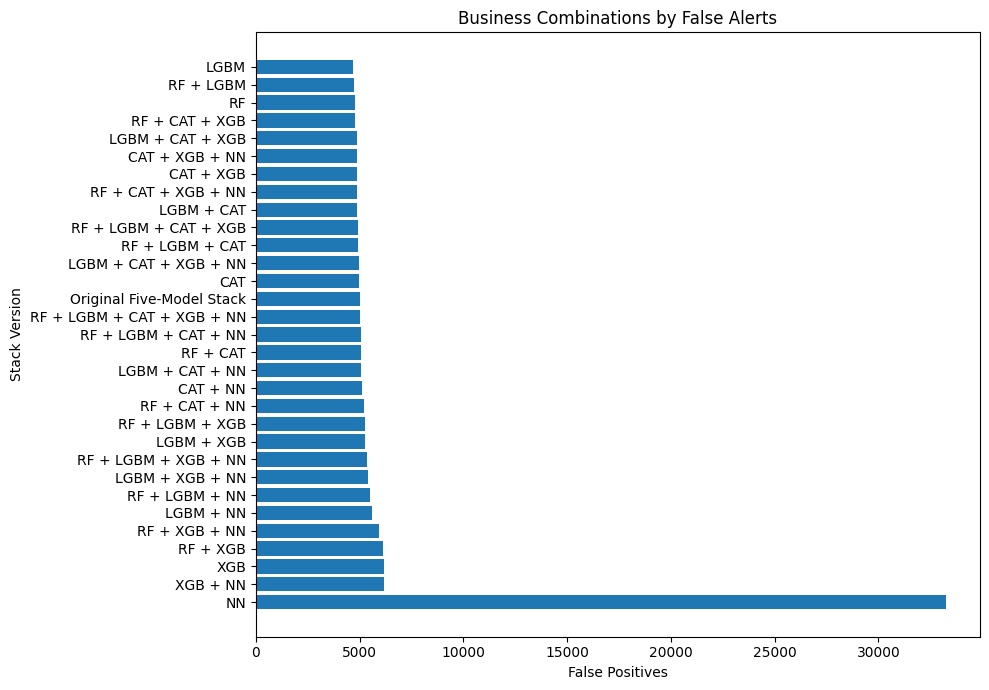

time: 644 ms (started: 2026-06-18 07:56:13 +00:00)


In [ ]:
plot_df = combined_business_df.head(TOP_N_TO_DISPLAY).copy()
plot_df = plot_df.sort_values("FP", ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(
    plot_df["Stack Version"],
    plot_df["FP"]
)

ax.set_xlabel("False Positives")
ax.set_ylabel("Stack Version")
ax.set_title(
    f"Business Combinations by False Alerts"
)

plt.tight_layout()

save_plot(
    fig,
    "top_business_combinations_false_positives.png"
)

plt.show()

## Precision and Recall for Top Business Combinations

Saved plot: /content/meta_feature_combination_study/figures/top_business_combinations_precision_recall.png


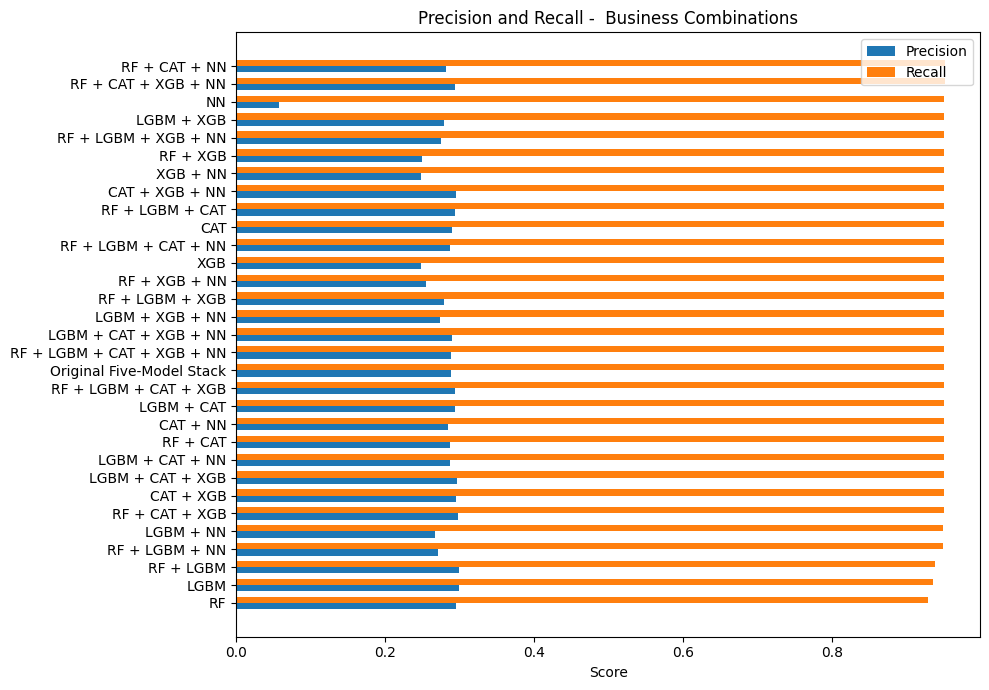

time: 659 ms (started: 2026-06-18 07:56:13 +00:00)


In [ ]:
plot_df = combined_business_df.head(TOP_N_TO_DISPLAY).copy()
plot_df = plot_df.sort_values("Recall", ascending=True)

y_positions = np.arange(len(plot_df))
bar_height = 0.35

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(
    y_positions - bar_height / 2,
    plot_df["Precision"],
    height=bar_height,
    label="Precision"
)

ax.barh(
    y_positions + bar_height / 2,
    plot_df["Recall"],
    height=bar_height,
    label="Recall"
)

ax.set_yticks(y_positions)
ax.set_yticklabels(plot_df["Stack Version"])

ax.set_xlabel("Score")
ax.set_title(
    f"Precision and Recall -  Business Combinations"
)

ax.legend()

plt.tight_layout()

save_plot(
    fig,
    "top_business_combinations_precision_recall.png"
)

plt.show()

## Best Combination by Number of Models

Saved plot: /content/meta_feature_combination_study/figures/false_alerts_by_stack_complexity.png


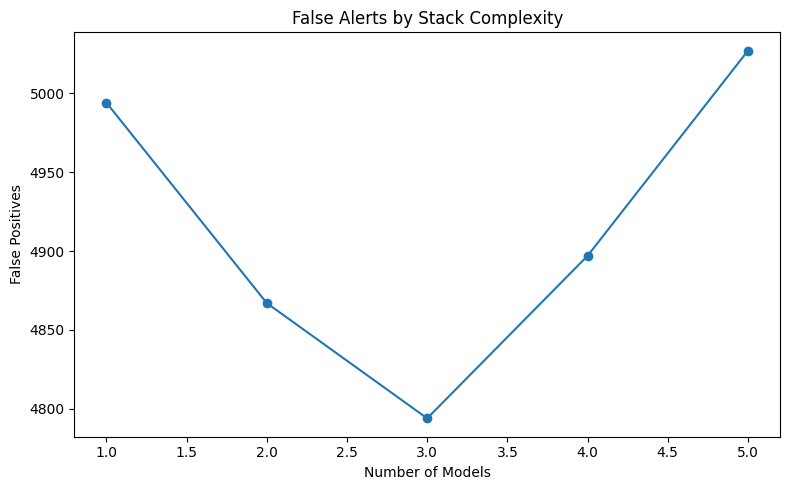

,Stack Version,Number of Models,Features,Threshold Type,Threshold,Precision,Recall,F1,Balanced Accuracy,ROC-AUC,PR-AUC,TN,FP,FN,TP,False Alarm Rate,Meets Minimum Recall
3,CAT,1,cat_prob,Optimized for Recall >= 0.95,0.73,0.289919,0.950583,0.444323,0.970781,0.997062,0.869363,548580.0,4994.0,106.0,2039.0,0.009021,True
1,CAT + XGB,2,cat_prob + xgb_prob,Optimized for Recall >= 0.95,0.71,0.295148,0.950117,0.450387,0.970662,0.997507,0.875752,548707.0,4867.0,107.0,2038.0,0.008792,True
0,RF + CAT + XGB,3,rf_prob + cat_prob + xgb_prob,Optimized for Recall >= 0.95,0.69,0.298302,0.950117,0.454049,0.970728,0.997511,0.880693,548780.0,4794.0,107.0,2038.0,0.008660,True
2,RF + CAT + XGB + NN,4,rf_prob + cat_prob + xgb_prob + nn_prob,Optimized for Recall >= 0.95,0.68,0.294075,0.951049,0.449240,0.971101,0.997342,0.880833,548677.0,4897.0,105.0,2040.0,0.008846,True
4,RF + LGBM + CAT + XGB + NN,5,rf_prob + lgbm_prob + cat_prob + xgb_prob + nn...,Optimized for Recall >= 0.95,0.56,0.288464,0.950117,0.442562,0.970518,0.997130,0.862644,548547.0,5027.0,107.0,2038.0,0.009081,True


time: 337 ms (started: 2026-06-18 07:56:14 +00:00)


In [ ]:
plot_df = best_by_model_count_df.sort_values("Number of Models")

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    plot_df["Number of Models"],
    plot_df["FP"],
    marker="o"
)

ax.set_xlabel("Number of Models")
ax.set_ylabel("False Positives")
ax.set_title("False Alerts by Stack Complexity")

plt.tight_layout()

save_plot(
    fig,
    "false_alerts_by_stack_complexity.png"
)

plt.show()

display(plot_df)

# Confusion Matrices

Instead of plotting 31 confusion matrices, this notebook plots only the most important candidates:

1. Best business model
2. Best small stack candidate
3. Original five-model stack

This keeps the notebook focused and easier to explain.

In [ ]:
def get_probabilities_for_stack(stack_name):
    if stack_name == "Original Five-Model Stack":
        return original_reference_prob

    return trained_experiments[stack_name]["test_prob"]


important_candidates = []

important_candidates.append({
    "Name": best_business_model["Stack Version"],
    "Threshold": best_business_model["Threshold"],
    "Reason": "Best Business Model",
})

important_candidates.append({
    "Name": best_small_stack["Stack Version"],
    "Threshold": best_small_stack["Threshold"],
    "Reason": "Best Small Stack",
})

important_candidates.append({
    "Name": "Original Five-Model Stack",
    "Threshold": original_reference_row["Threshold"],
    "Reason": "Original Reference",
})

important_candidates_df = pd.DataFrame(important_candidates).drop_duplicates(
    subset=["Name", "Threshold"]
)

display(important_candidates_df)

,Name,Threshold,Reason
0,RF + CAT + XGB,0.69,Best Business Model
1,CAT,0.73,Best Small Stack
2,Original Five-Model Stack,0.56,Original Reference


time: 13.6 ms (started: 2026-06-18 07:56:14 +00:00)


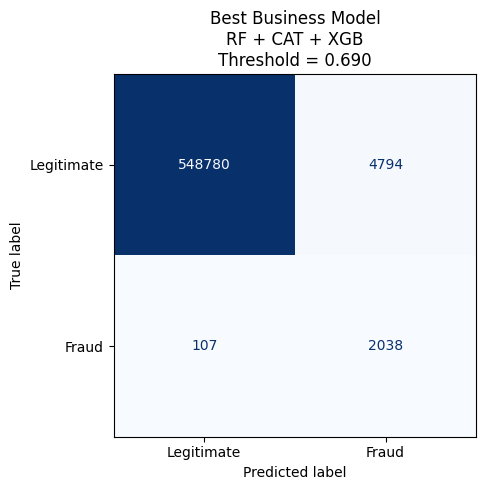

TN: 548780
FP: 4794
FN: 107
TP: 2038
Saved plot: /content/meta_feature_combination_study/figures/best_business_model_rf_plus_cat_plus_xgb_confusion_matrix.png


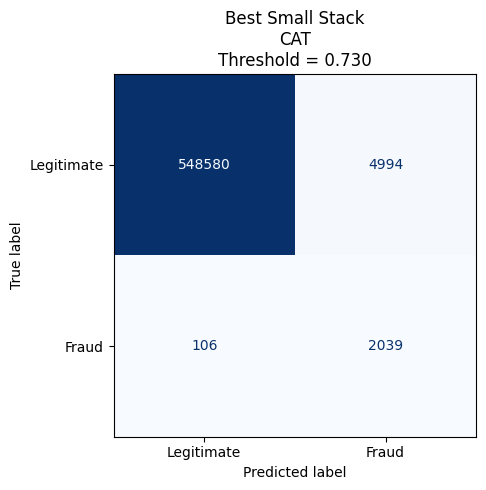

TN: 548580
FP: 4994
FN: 106
TP: 2039
Saved plot: /content/meta_feature_combination_study/figures/best_small_stack_cat_confusion_matrix.png


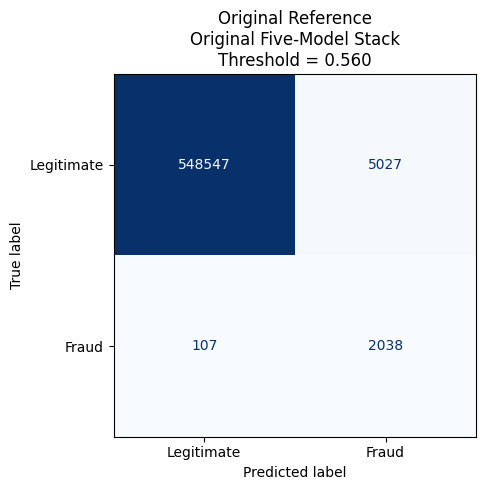

TN: 548547
FP: 5027
FN: 107
TP: 2038
Saved plot: /content/meta_feature_combination_study/figures/original_reference_original_five_model_stack_confusion_matrix.png
time: 548 ms (started: 2026-06-18 07:56:14 +00:00)


In [ ]:
for _, candidate in important_candidates_df.iterrows():
    stack_name = candidate["Name"]
    threshold = candidate["Threshold"]
    reason = candidate["Reason"]

    probabilities = get_probabilities_for_stack(stack_name)

    title = (
        f"{reason}\n"
        f"{stack_name}\n"
        f"Threshold = {threshold:.3f}"
    )

    fig = plot_confusion_matrix(
        y_true=y_test,
        y_prob=probabilities,
        threshold=threshold,
        title=title
    )

    filename = (
        clean_model_name(reason)
        + "_"
        + clean_model_name(stack_name)
        + "_confusion_matrix.png"
    )

    save_plot(
        fig,
        filename
    )

# Threshold Curve for Final Candidate

This plot shows how precision and recall change across thresholds for the selected business model.

It helps explain why the selected threshold was chosen.

Saved plot: /content/meta_feature_combination_study/figures/final_candidate_threshold_sweep.png


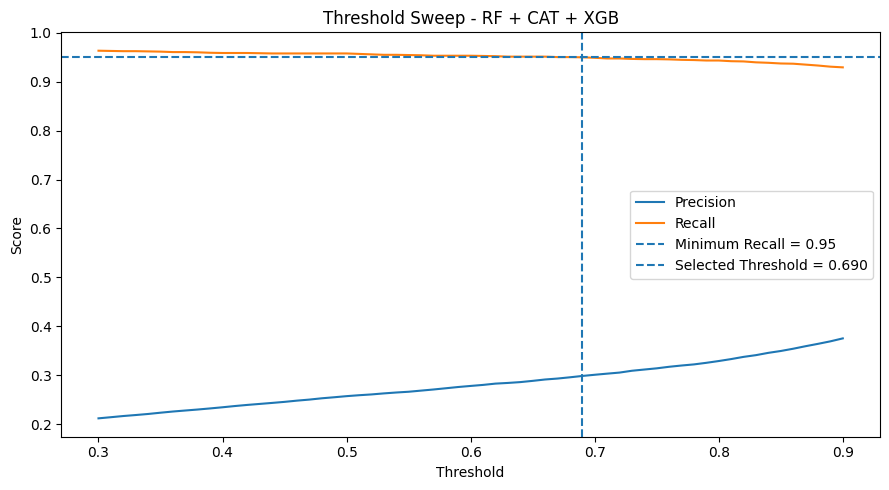

time: 359 ms (started: 2026-06-18 07:56:15 +00:00)


In [ ]:
final_candidate_name = best_business_model["Stack Version"]

if final_candidate_name == "Original Five-Model Stack":
    final_threshold_df = original_threshold_df.copy()
else:
    final_threshold_df = threshold_sweeps[final_candidate_name].copy()

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    final_threshold_df["Threshold"],
    final_threshold_df["Precision"],
    label="Precision"
)

ax.plot(
    final_threshold_df["Threshold"],
    final_threshold_df["Recall"],
    label="Recall"
)

ax.axhline(
    MINIMUM_RECALL,
    linestyle="--",
    label=f"Minimum Recall = {MINIMUM_RECALL}"
)

ax.axvline(
    best_business_threshold,
    linestyle="--",
    label=f"Selected Threshold = {best_business_threshold:.3f}"
)

ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.set_title(
    f"Threshold Sweep - {final_candidate_name}"
)

ax.legend()

plt.tight_layout()

save_plot(
    fig,
    "final_candidate_threshold_sweep.png"
)

plt.show()

# Save Final Production Stack Artifacts


In [ ]:
SELECTED_STACK_NAME = "RF + CAT + XGB"

selected_experiment = trained_experiments[SELECTED_STACK_NAME]

production_stack_artifacts = {
    "stack_name": SELECTED_STACK_NAME,
    "feature_set": selected_experiment["feature_set"],
    "meta_model": selected_experiment["meta_model"],
    "threshold": float(selected_experiment["best_threshold"]),
    "minimum_recall": MINIMUM_RECALL,
    "results": selected_experiment["results"],
    "coefficients": selected_experiment["coefficients"],
}

production_stack_path = os.path.join(
    ARTIFACT_DIR,
    "production_stack_artifacts.joblib"
)

joblib.dump(
    production_stack_artifacts,
    production_stack_path
)

print("Production stack artifacts saved:")
print(production_stack_path)

Production stack artifacts saved:
/content/fraud_stacking_artifacts/production_stack_artifacts.joblib
time: 3.13 ms (started: 2026-06-18 07:57:49 +00:00)


## Verify Saved Production Stack


In [ ]:
loaded_stack = joblib.load(
    os.path.join(
        ARTIFACT_DIR,
        "production_stack_artifacts.joblib"
    )
)

print("Stack Name:")
print(loaded_stack["stack_name"])

print("\nFeature Set:")
print(loaded_stack["feature_set"])

print("\nThreshold:")
print(loaded_stack["threshold"])

print("\nMeta Model:")
print(type(loaded_stack["meta_model"]))

Stack Name:
RF + CAT + XGB

Feature Set:
('rf_prob', 'cat_prob', 'xgb_prob')

Threshold:
0.69

Meta Model:
<class 'sklearn.linear_model._logistic.LogisticRegression'>
time: 2.21 ms (started: 2026-06-18 07:57:49 +00:00)


## Save Final Results Table


In [ ]:
final_results_path = os.path.join(
    REPORTS_DIR,
    "final_stack_comparison.csv"
)

print("Saved:")
print(final_results_path)

Saved:
/content/meta_feature_combination_study/reports/final_stack_comparison.csv
time: 643 µs (started: 2026-06-18 07:58:16 +00:00)


## Save Selected Threshold Sweep

In [ ]:
selected_threshold_sweep = threshold_sweeps[
    SELECTED_STACK_NAME
]

selected_threshold_path = os.path.join(
    THRESHOLD_DIR,
    "production_threshold_sweep.csv"
)

selected_threshold_sweep.to_csv(
    selected_threshold_path,
    index=False
)

print("Saved:")
print(selected_threshold_path)

Saved:
/content/meta_feature_combination_study/reports/threshold_sweeps/production_threshold_sweep.csv
time: 2.81 ms (started: 2026-06-18 07:58:33 +00:00)


# Notebook Summary

This notebook evaluated all possible meta-feature combinations generated from the five base-model probability outputs:

- Random Forest
- LightGBM
- CatBoost
- XGBoost
- Neural Network

A total of 31 non-empty combinations were tested.

For each combination:

1. A Logistic Regression meta-model was trained using the saved OOF meta-features.
2. Predictions were generated on the saved test meta-features.
3. A threshold sweep was performed.
4. The best threshold was selected according to the business constraint:
   - Recall ≥ 0.95
   - Minimum False Positives
   - Higher Precision when ties occurred

The resulting combinations were compared against the original five-model stacking ensemble.

Additional analysis included:

- Business performance comparison
- Threshold optimization
- Complexity analysis
- Small-stack candidate selection
- Confusion matrix evaluation
- Threshold behavior analysis

The selected production stack artifacts were saved for downstream inference and backend integration.